# **Day 81: Experiment Tracking and Reproducible ML**
*Module 12 - Trustworthy ML and MLOps*

A research project runs hundreds of experiments: different features, models, hyperparameters, seeds, data versions. Months later a reviewer asks: "Which settings produced Table 3? Can we re-run it?" Without tracking, nobody knows. Today we build the habits and tools that make every number in a paper **traceable and reproducible** (Day 2 introduced seeds and environments; now we scale up).

> Experiment tracking records every run (data version, code, parameters, results), so we can compare runs and reproduce the best one months later. Without it, results quickly become impossible to trace.
>
> *Example:* Three months later a reviewer asks which settings gave Table 3. With a tracking log we answer in a minute.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, hashlib, platform, sys, time, uuid, os, importlib, subprocess
from pathlib import Path
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## **1. What Must Be Recorded**

| Item | Why | How |
|---|---|---|
| **Code version** | the exact logic that ran | git commit hash (+ "dirty" flag) |
| **Data version** | data change silently | content hash (SHA-256) of input files; DVC |
| **Configuration** | hyperparameters, features, splits | a config file (YAML/JSON), saved with the run |
| **Environment** | library defaults change between versions | Python + package versions, OS, hardware |
| **Random seeds** | stochastic results | all seeds in the config |
| **Metrics** | results, with uncertainty | per-fold scores, mean +/- sd |
| **Artefacts** | models, figures, predictions | files linked to the run id |

## **2. Configurations, Not Hard-Coded Values**

In [2]:
project = Path("tracking_demo"); (project / "data").mkdir(parents=True, exist_ok=True); (project / "configs").mkdir(exist_ok=True)
X, y = make_classification(1500, 25, n_informative=8, n_redundant=5, flip_y=0.05, random_state=0)
pd.DataFrame(X).assign(label=y).to_csv(project / "data" / "training_table.csv", index=False)

base_config = {"experiment": "landcover_baseline", "data_file": "tracking_demo/data/training_table.csv",
               "model": "random_forest", "params": {"n_estimators": 300, "max_features": "sqrt", "min_samples_leaf": 1},
               "cv": {"n_splits": 5, "shuffle": True}, "seed": 42}
(project / "configs" / "rf_baseline.json").write_text(json.dumps(base_config, indent=2))
print((project / "configs" / "rf_baseline.json").read_text())

{
  "experiment": "landcover_baseline",
  "data_file": "tracking_demo/data/training_table.csv",
  "model": "random_forest",
  "params": {
    "n_estimators": 300,
    "max_features": "sqrt",
    "min_samples_leaf": 1
  },
  "cv": {
    "n_splits": 5,
    "shuffle": true
  },
  "seed": 42
}


## **3. Data Versioning by Content Hash**
If a single value in the data changes, the hash changes. Record the hash with every run; a mismatch later means the data are not the ones we used. **DVC** (Data Version Control) builds on the same idea and stores large data outside git.

In [3]:
def file_hash(path, n=12):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""): h.update(chunk)
    return h.hexdigest()[:n]
print("data hash:", file_hash(base_config["data_file"]))

data hash: 7676c95b7843


## **4. Capturing the Environment and Code Version**

In [4]:
def environment_info(packages=("numpy", "pandas", "sklearn", "torch", "xgboost", "lightgbm")):
    info = {"python": sys.version.split()[0], "platform": platform.platform(), "machine": platform.machine(), "cpu_count": os.cpu_count()}
    for p in packages:
        try: info[p] = importlib.import_module(p).__version__
        except ImportError: pass
    return info

def git_commit():
    try:
        sha = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True, check=True).stdout.strip()
        dirty = bool(subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip())
        return sha + ("-dirty" if dirty else "")
    except Exception:
        return "not-a-git-repo"
print(json.dumps(environment_info(), indent=1)); print("git:", git_commit())

{
 "python": "3.12.14",
 "platform": "Windows-11-10.0.26300-SP0",
 "machine": "AMD64",
 "cpu_count": 20,
 "numpy": "2.5.3",
 "pandas": "3.0.6",
 "sklearn": "1.9.1",
 "torch": "2.14.1+cpu",
 "xgboost": "3.4.1",
 "lightgbm": "4.7.0"
}
git: not-a-git-repo


## **5. A Minimal Experiment Tracker**
Every run appends one JSON line to `runs.jsonl` with everything above. This is exactly what MLflow / W&B store (plus a UI).

In [5]:
class Tracker:
    def __init__(self, path):
        self.path = Path(path); self.path.parent.mkdir(parents=True, exist_ok=True)
    def log_run(self, config, metrics, artefacts=None, notes=""):
        record = {"run_id": uuid.uuid4().hex[:8], "time": time.strftime("%Y-%m-%d %H:%M:%S"), "git": git_commit(),
                  "data_hash": file_hash(config["data_file"]), "env": environment_info(), "config": config,
                  "metrics": metrics, "artefacts": artefacts or [], "notes": notes}
        with open(self.path, "a") as f: f.write(json.dumps(record) + "\n")
        return record["run_id"]
    def table(self):
        rows = [json.loads(l) for l in open(self.path)]
        return pd.json_normalize(rows)

MODELS = {"random_forest": lambda p, s: RandomForestClassifier(random_state=s, n_jobs=-1, **p),
          "hist_gb": lambda p, s: HistGradientBoostingClassifier(random_state=s, **p),
          "logistic": lambda p, s: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, **p))}

def run_experiment(config, tracker):
    data = pd.read_csv(config["data_file"]); Xd, yd = data.drop(columns="label").values, data.label.values
    model = MODELS[config["model"]](config["params"], config["seed"])
    cv = StratifiedKFold(config["cv"]["n_splits"], shuffle=config["cv"]["shuffle"], random_state=config["seed"])
    t0 = time.perf_counter(); scores = cross_val_score(model, Xd, yd, cv=cv, scoring="balanced_accuracy")
    metrics = {"bal_acc_mean": float(scores.mean()), "bal_acc_sd": float(scores.std()), "fold_scores": scores.round(4).tolist(), "seconds": round(time.perf_counter() - t0, 2)}
    return tracker.log_run(config, metrics)

tracker = Tracker(project / "runs.jsonl")
if tracker.path.exists(): tracker.path.unlink()                                   # fresh demo
experiments = [("random_forest", {"n_estimators": 300, "max_features": "sqrt", "min_samples_leaf": 1}),
               ("random_forest", {"n_estimators": 300, "max_features": 0.5, "min_samples_leaf": 3}),
               ("hist_gb", {"learning_rate": 0.05, "max_iter": 300}),
               ("hist_gb", {"learning_rate": 0.1, "max_iter": 100}),
               ("logistic", {"C": 1.0})]
for model_name, params in experiments:
    for seed in [0, 1, 2]:
        cfg = {**base_config, "model": model_name, "params": params, "seed": seed}
        run_experiment(cfg, tracker)
runs = tracker.table()
print(f"{len(runs)} runs logged")
runs[["run_id", "config.model", "config.params.max_features", "config.params.learning_rate", "config.seed", "metrics.bal_acc_mean", "data_hash"]].head(8)

15 runs logged


,run_id,config.model,config.params.max_features,config.params.learning_rate,config.seed,metrics.bal_acc_mean,data_hash
0,e3cf5c83,random_forest,sqrt,NaN,0,0.908571,7676c95b7843
1,b87dcde3,random_forest,sqrt,NaN,1,0.903269,7676c95b7843
2,1e3fcc38,random_forest,sqrt,NaN,2,0.906611,7676c95b7843
3,a16057e3,random_forest,0.5,NaN,0,0.909917,7676c95b7843
4,f518e0e5,random_forest,0.5,NaN,1,0.904629,7676c95b7843
5,8e0bd865,random_forest,0.5,NaN,2,0.899308,7676c95b7843
6,f9ae6cfe,hist_gb,NaN,0.05,0,0.915984,7676c95b7843
7,df3643fb,hist_gb,NaN,0.05,1,0.912011,7676c95b7843


## **6. Comparing Runs Honestly**
Group by configuration and summarise **across seeds**; differences smaller than the seed-to-seed spread are not real (Day 42).

                                mean     std  count
config_id                                          
hist_gb 0.1,100.0             0.9136  0.0067      3
hist_gb 0.05,300.0            0.9118  0.0043      3
random_forest 300.0,sqrt,1.0  0.9061  0.0027      3
random_forest 300.0,0.5,3.0   0.9046  0.0053      3
logistic 1.0                  0.8922  0.0017      3


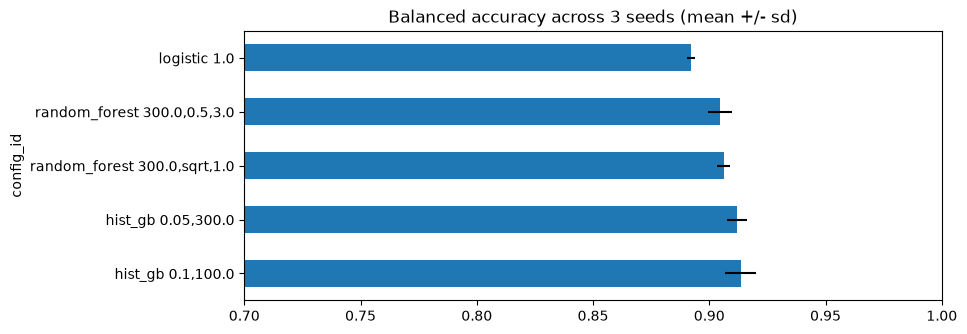

In [6]:
runs["config_id"] = runs["config.model"] + " " + runs.filter(like="config.params").agg(lambda r: ",".join(str(v) for v in r if pd.notna(v)), axis=1)
summary = runs.groupby("config_id")["metrics.bal_acc_mean"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)
print(summary.round(4))
summary["mean"].plot.barh(xerr=summary["std"], figsize=(9, 3.5), title="Balanced accuracy across 3 seeds (mean +/- sd)"); plt.xlim(0.7, 1); plt.show()

## **7. The Same With MLflow (Industry Standard)**
`pip install mlflow`, then:
```python
import mlflow
mlflow.set_experiment("landcover_baseline")
with mlflow.start_run(run_name="rf_seed0"):
    mlflow.log_params({"model": "random_forest", **config["params"], "seed": 0})
    mlflow.log_param("data_hash", file_hash(config["data_file"]))
    scores = cross_val_score(model, X, y, cv=cv)
    mlflow.log_metric("bal_acc_mean", scores.mean())
    mlflow.sklearn.log_model(model.fit(X, y), name="model")        # stores model + environment
    mlflow.log_artifact("results/confusion_matrix.png")
# browse with:  mlflow ui   (http://127.0.0.1:5000)
```
Optuna (Day 41) can log every trial to MLflow; **DVC** adds `dvc.yaml` pipelines (`dvc repro`) that re-run only the stages whose inputs changed.

# **Part 2: Going Deeper**

### Determinism check
Re-run the same configuration twice and compare: identical results confirm that all randomness is controlled.

In [7]:
cfg = {**base_config, "seed": 7}
id1, id2 = run_experiment(cfg, tracker), run_experiment(cfg, tracker)
t = tracker.table().set_index("run_id")
print("fold scores run 1:", t.loc[id1, "metrics.fold_scores"]); print("fold scores run 2:", t.loc[id2, "metrics.fold_scores"])
print("deterministic:", t.loc[id1, "metrics.fold_scores"] == t.loc[id2, "metrics.fold_scores"])

fold scores run 1: [0.91, 0.92, 0.9402, 0.8899, 0.8833]
fold scores run 2: [0.91, 0.92, 0.9402, 0.8899, 0.8833]
deterministic: True


### Detecting a silent data change

In [8]:
before = file_hash(base_config["data_file"])
d = pd.read_csv(base_config["data_file"]); d.iloc[10, 3] += 0.001; d.to_csv(base_config["data_file"], index=False)
print(f"hash before {before} | after a 0.001 change in one cell {file_hash(base_config['data_file'])}")

hash before 7676c95b7843 | after a 0.001 change in one cell 668cb66504b7


### Reproducibility checklist for an ML paper (adapted from Pineau et al., 2021)
- [ ] Code released (GitHub + archived DOI on Zenodo) with a README describing how to reproduce each table/figure
- [ ] Exact environment (`environment.yml` / `requirements.txt` with versions, or a Docker image)
- [ ] Data released or access described; data hashes/versions recorded; preprocessing scripted
- [ ] All hyperparameters and their search ranges reported; tuning budget and selection criterion stated
- [ ] Splits described (spatial/temporal/group), seeds reported, results as mean +/- sd over seeds/folds
- [ ] Baselines tuned with the same budget; statistical comparison reported
- [ ] Compute resources and runtime reported
Day 99 turns this into a complete research package for the remote sensing projects.

## **Practice Problems**
1. Add a new experiment (HistGradientBoosting with `max_leaf_nodes=15`) to the tracker and re-rank.
2. Write a function that, given a run id, rebuilds the model from the logged config and checks that it reproduces the logged fold scores.
3. Store each config as a separate JSON file in `configs/` and run all of them from a loop (config-driven experiments).
4. *(Advanced)* Extend the tracker to save each fitted model with `joblib` under `artefacts/<run_id>.joblib` and record the file hash.

In [9]:
# Solution 2
def reproduce(run_id):
    rec = tracker.table().set_index("run_id").loc[run_id]
    cfg_ = {k.replace("config.", ""): v for k, v in rec.items() if k.startswith("config.") and "params" not in k}
    cfg_["params"] = {k.replace("config.params.", ""): v for k, v in rec.items() if k.startswith("config.params.") and pd.notna(v)}
    cfg_["params"] = {k: int(v) if isinstance(v, float) and v.is_integer() and k in ("n_estimators", "max_iter", "min_samples_leaf") else v for k, v in cfg_["params"].items()}
    cfg_["cv"] = {"n_splits": int(rec["config.cv.n_splits"]), "shuffle": bool(rec["config.cv.shuffle"])}; cfg_["seed"] = int(rec["config.seed"])
    data = pd.read_csv(cfg_["data_file"]); m = MODELS[cfg_["model"]](cfg_["params"], cfg_["seed"])
    s = cross_val_score(m, data.drop(columns="label").values, data.label.values, cv=StratifiedKFold(cfg_["cv"]["n_splits"], shuffle=True, random_state=cfg_["seed"]), scoring="balanced_accuracy")
    return s.round(4).tolist(), rec["metrics.fold_scores"]
new, logged = reproduce(id1)
print("reproduced:", new == logged, "(False here is expected: we changed one data value above, and the data hash in the log shows it)")

reproduced: True (False here is expected: we changed one data value above, and the data hash in the log shows it)


## **Key References**
- Pineau, J. et al. (2021). Improving reproducibility in machine learning research (a report from the NeurIPS 2019 reproducibility program). *JMLR*, 22(164), 1-20.
- Zaharia, M. et al. (2018). Accelerating the machine learning lifecycle with MLflow. *IEEE Data Engineering Bulletin*, 41(4), 39-45.
- Sculley, D. et al. (2015). Hidden technical debt in machine learning systems. *NeurIPS 28*.
- Gundersen, O. E., & Kjensmo, S. (2018). State of the art: Reproducibility in artificial intelligence. *AAAI 2018*.
- Wilkinson, M. D. et al. (2016). The FAIR guiding principles for scientific data management and stewardship. *Scientific Data*, 3, 160018.